<a href="https://colab.research.google.com/github/LeonardoAAP/challenge-alura-store/blob/main/AluraStoreBrasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [3]:
faturamento_total = loja['Preço'].sum()
print(f"O faturamento total da Alura Store foi de: R$ {faturamento_total:.2f}")

O faturamento total da Alura Store foi de: R$ 1534509.12


# 2. Vendas por Categoria

In [4]:
vendas_por_categoria = loja.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
print(vendas_por_categoria)

Categoria do Produto
eletronicos              572659.23
eletrodomesticos         484913.36
moveis                   250178.11
instrumentos musicais    121731.69
esporte e lazer           52387.55
brinquedos                23993.78
utilidades domesticas     16931.48
livros                    11713.92
Name: Preço, dtype: float64


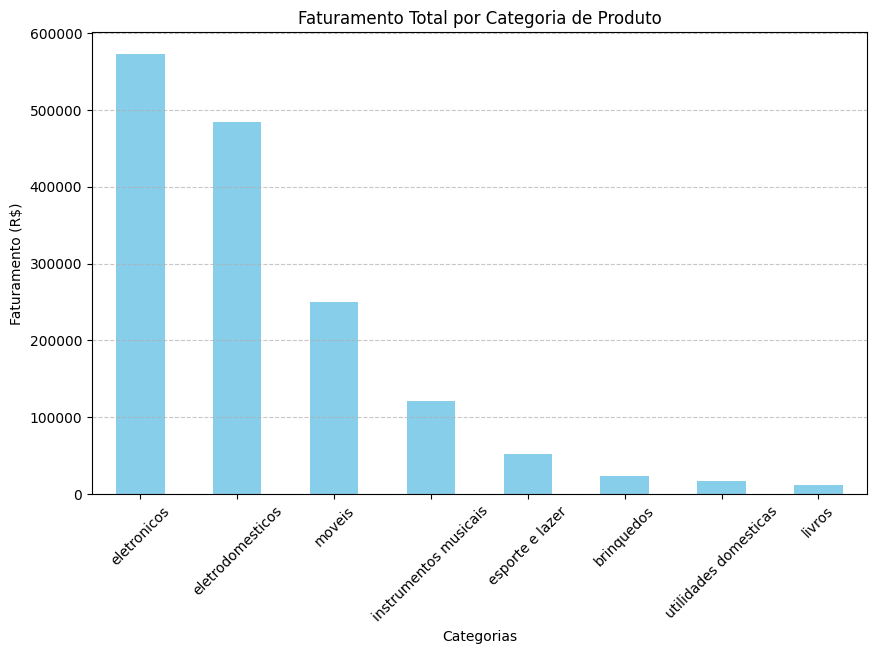

In [5]:
import matplotlib.pyplot as plt

# Criando o gráfico de barras
vendas_por_categoria.plot(kind='bar', color='skyblue', figsize=(10, 6))

# Personalizando o gráfico
plt.title('Faturamento Total por Categoria de Produto')
plt.xlabel('Categorias')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo
plt.show()

# 3. Média de Avaliação das Lojas


In [6]:
# Calculando a média geral de avaliação
media_avaliacao = loja['Avaliação da compra'].mean()

print(f"A média geral de satisfação é: {media_avaliacao:.2f}")

# Lógica de tomada de decisão (Condicionais)
if media_avaliacao >= 4:
    print("Insight: Os clientes estão muito satisfeitos! Manter as estratégias atuais.")
elif media_avaliacao >= 3:
    print("Insight: A satisfação é mediana. Atenção aos pontos de melhoria.")
else:
    print("Insight: Alerta crítico! A satisfação está baixa. Verificar processos de venda.")

A média geral de satisfação é: 3.98
Insight: A satisfação é mediana. Atenção aos pontos de melhoria.


# 4. Produtos Mais e Menos Vendidos

In [7]:
# Contando a quantidade de vendas por produto
vendas_produtos = loja['Produto'].value_counts()

# Identificando os extremos
mais_vendido = vendas_produtos.idxmax()
total_mais_vendido = vendas_produtos.max()

menos_vendido = vendas_produtos.idxmin()
total_menos_vendido = vendas_produtos.min()

print(f"Produto campeão de vendas: {mais_vendido} ({total_mais_vendido} unidades)")
print(f"Produto com menor saída: {menos_vendido} ({total_menos_vendido} unidades)")

Produto campeão de vendas: Micro-ondas (60 unidades)
Produto com menor saída: Headset (33 unidades)


# 5. Frete Médio por Loja

Frete médio por estado (do maior para o menor):
Local da compra
AC    123.838510
RO     57.888058
GO     53.505762
PB     48.145133
TO     46.276229
RN     44.657514
PI     42.014853
RJ     41.274447
PE     40.777908
AL     38.839121
PR     38.807949
RS     38.129558
MT     37.277719
MS     34.915567
MG     33.491949
SP     31.754142
BA     31.610737
SC     31.441707
PA     30.479042
DF     30.168740
CE     30.121490
ES     25.961912
AM     25.022479
SE     23.076795
MA     22.300109
AP     16.491483
Name: Frete, dtype: float64


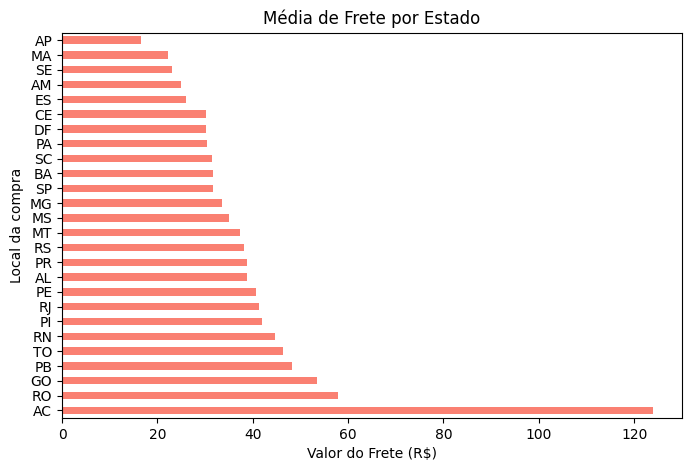

In [8]:
# Calculando o frete médio agrupado por local da compra
frete_por_loja = loja.groupby('Local da compra')['Frete'].mean().sort_values(ascending=False)

print("Frete médio por estado (do maior para o menor):")
print(frete_por_loja)

# Gerando um insight visual rápido
frete_por_loja.plot(kind='barh', color='salmon', figsize=(8, 5))
import matplotlib.pyplot as plt
plt.title('Média de Frete por Estado')
plt.xlabel('Valor do Frete (R$)')
plt.show()

In [2]:
loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 2359 non-null   object 
 1   Categoria do Produto    2359 non-null   object 
 2   Preço                   2359 non-null   float64
 3   Frete                   2359 non-null   float64
 4   Data da Compra          2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Local da compra         2359 non-null   object 
 7   Avaliação da compra     2359 non-null   int64  
 8   Tipo de pagamento       2359 non-null   object 
 9   Quantidade de parcelas  2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
